<a href="https://colab.research.google.com/github/denys-babak/data-cleaning/blob/main/%5BNOTEBOOK%5D_2_Data_Quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import seaborn as sns



pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)

url = 'https://drive.google.com/file/d/1cje_pWKwk-eu-UJaW35C6wVp2jypPOhG/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
products = pd.read_csv(path)

url = 'https://drive.google.com/file/d/19937MldB9uEmUkY-XJEXqJFrvOIsSh-B/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
orders = pd.read_csv(path)

url = 'https://drive.google.com/file/d/1R2AWeVvsKO_Z3gOPYU3zcj2VV1s7JHvI/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
orderlines = pd.read_csv(path)

url = 'https://drive.google.com/file/d/1r_d9-hQflMgkQW4WSVCfqVojD0aVwU5h/view?usp=drive_link'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
brands = pd.read_csv(path)


In [ ]:
# create DF copies

df_orders = orders.copy()
df_orderlines = orderlines.copy()
df_products = products.copy()

# remove unfinished orders

mask_not_finished_orders = df_orders['state'].isin(["Cancelled", "Shopping Basket", "Pending"])
df_orders.loc[mask_not_finished_orders]
df_orders = df_orders[~mask_not_finished_orders]

In [ ]:
# check that all skus in the orderlines and products match
df_orderlines_sku = df_orderlines.copy()
validation =df_orderlines_sku['sku'].astype(str).isin(df_products['sku'].astype(str))
df_orderlines_sku.loc[validation]

df_orderlines_sku = df_orderlines_sku[validation]
df_orderlines_sku

,orderline_id,order_id,product_quantity,sku,unit_price,order_date,name,order_date_only
0,1119109,299539,1,OTT0133,18.99,2017-01-01 00:07:19,Otterbox iPhone Case Symmetry 2.0 SE / 5s / 5 ...,2017-01-01
1,1119110,299540,1,LGE0043,399.00,2017-01-01 00:19:45,"27UD58-B LG Monitor 27 ""4K UHD DisplayPort",2017-01-01
2,1119111,299541,1,PAR0071,474.05,2017-01-01 00:20:57,Parrot Bebop 2 White + Command FLYPAD and FPV ...,2017-01-01
3,1119112,299542,1,WDT0315,68.39,2017-01-01 00:51:40,"Blue WD 2TB Hard Drive 35 ""Mac and PC",2017-01-01
4,1119114,295310,10,WDT0249,231.79,2017-01-01 01:14:27,"WD Red 6TB 35 ""Mac PC hard drive and NAS",2017-01-01
...,...,...,...,...,...,...,...,...
238304,1650199,527398,1,JBL0122,42.99,2018-03-14 13:57:25,JBL T450 BT Bluetooth Headset Black,2018-03-14
238305,1650200,527399,1,PAC0653,141.58,2018-03-14 13:57:34,Samsung SSD 850 expansion kit EVO 250GB + Data...,2018-03-14
238306,1650201,527400,2,APP0698,9.99,2018-03-14 13:57:41,Apple Lightning Cable Connector to USB 1m Whit...,2018-03-14
238307,1650202,527388,1,BEZ0204,19.99,2018-03-14 13:58:01,"Be.ez LArobe Case Mix Macbook 12 ""Green",2018-03-14


In [ ]:
repair_mask = df_products["desc"].astype(str).str.contains("Repair service", case=False, na=False)
df_products[repair_mask]

,sku,name,desc,promo_price,price,in_stock,type
200,REP0036,Full screen repair iPhone 4,Repair service including parts and labor for i...,49.99,49.99,0,"1,44E+11"
201,REP0040,Home button repair iPhone 4,Repair service including parts and labor for i...,49.99,49.99,0,"1,44E+11"
202,REP0041,battery repair iPhone 4,Repair service including parts and labor for i...,29.99,29.99,0,"1,44E+11"
204,REP0046,iPhone 4 front camera repair,Repair service including parts and labor for i...,39.99,39.99,0,"1,44E+11"
205,REP0050,Headset calls iPhone 4 Repair,Repair service including parts and labor for i...,39.99,39.99,0,"1,44E+11"
206,REP0051,Load Connector Repair iPhone 4,Repair service including parts and labor for i...,39.99,39.99,0,"1,44E+11"
214,REP0059,iPhone 4s Home button repair,Repair service including parts and labor for i...,49.90,49.99,0,"1,44E+11"
216,REP0064,iPhone 4s front camera repair,Repair service including parts and labor for i...,49.90,49.99,0,"1,44E+11"
217,REP0068,Headset calls iPhone 4s repair,Repair service including parts and labor for i...,39.99,39.99,0,"1,44E+11"
219,REP0073,Repair Touch Screen iPad (1st generation),Repair service including parts and labor for iPad,99.99,99.99,0,"1,44E+11"


In [ ]:
#remove repair services from all tables

repair_mask = df_products["desc"].astype(str).str.contains("Repair", case=False, na=False)
repair_skus = df_products.loc[repair_mask, "sku"]

repair_order_ids = df_orderlines_sku[df_orderlines_sku["sku"].isin(repair_skus)]["order_id"].unique()

df_orders = df_orders[~df_orders["order_id"].isin(repair_order_ids)] # remove those ids from orders
df_orderlines_sku = df_orderlines_sku[~df_orderlines_sku["order_id"].isin(repair_order_ids)] # remove those ids from orderlines
df_products = df_products[~df_products["sku"].isin(repair_skus)] # remove those ids from df_products

In [ ]:
# create an order_total and total_items columns
df_orderlines_unit_price_total = df_orderlines_sku.copy()

df_orderlines_unit_price_total['unit_price_total'] = df_orderlines_unit_price_total['unit_price'] * df_orderlines_unit_price_total['product_quantity']

orders_total = (
    df_orderlines_unit_price_total
    .groupby("order_id")
    .agg(
        order_total=("unit_price_total", "sum"),
        total_items=("product_quantity", "sum")
    )
    .reset_index()
)

# created a merged table 1 row = 1 order for simple analysis
df_merged_analysis = df_orderlines_unit_price_total.merge(orders_total, on="order_id")

In [ ]:
# merge orderlines with orders table to leave only orders / orders id that are present in both tables
orders_orderlines = df_merged_analysis.merge(df_orders, how="inner", on="order_id")


In [ ]:
# !!! # added a  filter b2c / b2b orders
df_merged_analysis["order_type"] = "B2C"
df_merged_analysis.loc[
    df_merged_analysis["product_quantity"] > 10,
    "order_type"
] = "B2B"


# exclude weird order
df_merged_analysis = df_merged_analysis.loc[
    df_merged_analysis["order_id"] != 331780
]
df_merged_analysis.loc[df_merged_analysis["product_quantity"]==11]

,orderline_id,order_id,product_quantity,sku,unit_price,order_date,name,order_date_only,unit_price_total,order_total,total_items,order_type
10782,1149334,310844,11,PIE0028,12.99,2017-01-17 10:25:24,internal battery for iPhone 5,2017-01-17,142.89,142.89,11,B2B
23723,1180199,324031,11,SAN0101,12.34,2017-02-14 12:52:03,SanDisk Ultra SDHC Class 10 | 32GB,2017-02-14,135.74,135.74,11,B2B
24699,1182464,324950,11,PHI0067,78.99,2017-02-15 22:45:03,Philips HUE LightStrips Plus LEDs Strip 2m,2017-02-15,868.89,3069.05,60,B2B
46938,1230705,347455,11,DLL0015,468.99,2017-04-19 16:13:58,"Dell U2715H Monitor 27 ""LED Slim Marco",2017-04-19,5158.89,5158.89,11,B2B
49401,1235944,349931,11,APP1210,179.00,2017-04-26 12:08:57,Apple TV 32GB media player,2017-04-26,1969.00,1969.00,11,B2B
73145,1284190,373484,11,WDT0316,50.99,2017-07-06 02:37:07,"Blue WD Hard Drive 1TB 35 ""Mac and PC",2017-07-06,560.89,560.89,11,B2B
126669,1407334,426707,11,LGE0036,175.00,2017-11-14 12:47:18,"25UM58-P Monitor LG 25 ""widescreen IPS UHD Ultra",2017-11-14,1925.00,1925.00,11,B2B
135502,1428495,434936,11,SEA0098,328.55,2017-11-23 15:42:20,IronWolf Seagate NAS HDD 10TB SATA 3,2017-11-23,3614.05,8728.12,12,B2B
167860,1496379,462808,11,NEA0020,76.00,2017-12-14 11:59:09,Netatmo intelligent radiator valve,2017-12-14,836.00,1018.99,12,B2B
167861,1496381,462809,11,NEA0020,69.09,2017-12-14 11:59:45,Netatmo intelligent radiator valve,2017-12-14,759.99,759.99,11,B2B


In [ ]:
order_ids = orders_orderlines["order_id"].unique()
order_ids

# keep those ids in orders
orders_qu = df_orders.loc[df_orders["order_id"].isin(order_ids), :]

# keep those ids in orderlines
orderlines_qu = df_orderlines_unit_price_total.loc[df_orderlines_unit_price_total["order_id"].isin(order_ids), :]

#keep them in a merged table
merged_qu = df_merged_analysis.loc[df_merged_analysis["order_id"].isin(order_ids), :]
merged_qu

,orderline_id,order_id,product_quantity,sku,unit_price,order_date,name,order_date_only,unit_price_total,order_total,total_items,order_type
6,1119116,299545,1,OWC0100,47.49,2017-01-01 01:46:16,OWC In-line Digital Temperature Sensor Kit HDD...,2017-01-01,47.49,47.49,1,B2C
7,1119119,299546,1,IOT0014,18.99,2017-01-01 01:50:34,iOttie Easy View 2 Car Black Support,2017-01-01,18.99,18.99,1,B2C
8,1119120,295347,1,APP0700,72.19,2017-01-01 01:54:11,Apple 85W MagSafe 2 charger MacBook Pro screen...,2017-01-01,72.19,72.19,1,B2C
9,1119126,299549,1,PAC0929,2565.99,2017-01-01 02:07:42,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",2017-01-01,2565.99,2565.99,1,B2C
11,1119131,299553,1,APP1854,3278.99,2017-01-01 02:14:47,"Apple MacBook Pro 13 ""with Touch Bar 33GHz Cor...",2017-01-01,3278.99,3278.99,1,B2C
...,...,...,...,...,...,...,...,...,...,...,...,...
235609,1650193,527394,1,APP1922,161.00,2018-03-14 13:55:15,AirPods Apple Bluetooth Headset for iPhone iPa...,2018-03-14,161.00,161.00,1,B2C
235611,1650195,527396,1,PAC0653,141.58,2018-03-14 13:55:44,Samsung SSD 850 expansion kit EVO 250GB + Data...,2018-03-14,141.58,141.58,1,B2C
235612,1650196,527384,1,LAC0227,249.99,2018-03-14 13:56:02,5TB Lacie Rugged Hard Disk Thunderbolt USB-C,2018-03-14,249.99,249.99,1,B2C
235613,1650198,527397,1,JBL0122,42.99,2018-03-14 13:56:38,JBL T450 BT Bluetooth Headset Black,2018-03-14,42.99,42.99,1,B2C


In [ ]:
# add total paid column to the merged table
merged_qu_with_paid_total = merged_qu.merge(
    df_orders[['order_id', 'total_paid']],
    on="order_id",
    how="inner"
)

new_column_order = [
    'order_id',
    'orderline_id',
    'sku',
    'product_quantity',
    'unit_price',
    'unit_price_total',
    'name',
    'order_total',
    'total_items',
    'total_paid',
    'order_date',
    'order_date_only',
    'order_type'
]

merged_qu_reordered = merged_qu_with_paid_total[new_column_order]
merged_qu_reordered

,order_id,orderline_id,sku,product_quantity,unit_price,unit_price_total,name,order_total,total_items,total_paid,order_date,order_date_only,order_type
0,299545,1119116,OWC0100,1,47.49,47.49,OWC In-line Digital Temperature Sensor Kit HDD...,47.49,1,51.48,2017-01-01 01:46:16,2017-01-01,B2C
1,299546,1119119,IOT0014,1,18.99,18.99,iOttie Easy View 2 Car Black Support,18.99,1,18.99,2017-01-01 01:50:34,2017-01-01,B2C
2,295347,1119120,APP0700,1,72.19,72.19,Apple 85W MagSafe 2 charger MacBook Pro screen...,72.19,1,72.19,2017-01-01 01:54:11,2017-01-01,B2C
3,299549,1119126,PAC0929,1,2565.99,2565.99,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",2565.99,1,2565.99,2017-01-01 02:07:42,2017-01-01,B2C
4,299553,1119131,APP1854,1,3278.99,3278.99,"Apple MacBook Pro 13 ""with Touch Bar 33GHz Cor...",3278.99,1,3278.99,2017-01-01 02:14:47,2017-01-01,B2C
...,...,...,...,...,...,...,...,...,...,...,...,...,...
85129,527394,1650193,APP1922,1,161.00,161.00,AirPods Apple Bluetooth Headset for iPhone iPa...,161.00,1,161.00,2018-03-14 13:55:15,2018-03-14,B2C
85130,527396,1650195,PAC0653,1,141.58,141.58,Samsung SSD 850 expansion kit EVO 250GB + Data...,141.58,1,141.58,2018-03-14 13:55:44,2018-03-14,B2C
85131,527384,1650196,LAC0227,1,249.99,249.99,5TB Lacie Rugged Hard Disk Thunderbolt USB-C,249.99,1,249.99,2018-03-14 13:56:02,2018-03-14,B2C
85132,527397,1650198,JBL0122,1,42.99,42.99,JBL T450 BT Bluetooth Headset Black,42.99,1,42.99,2018-03-14 13:56:38,2018-03-14,B2C


In [ ]:
# create diff column to check the difference between total_paid and order_total
merged_qu_reordered["order_t_paid_difference"] = merged_qu_reordered["total_paid"] - merged_qu_reordered["order_total"]
avg_diff = merged_qu_reordered["order_t_paid_difference"].mean()
avg_diff


/tmp/ipykernel_4211/3840162382.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  merged_qu_reordered["order_t_paid_difference"] = merged_qu_reordered["total_paid"] - merged_qu_reordered["order_total"]


np.float64(3.3420397256090393)

In [ ]:
merged_qu_with_outliers = merged_qu_reordered.copy()

In [ ]:
#define outliers
mask_outliers = merged_qu_with_outliers["order_t_paid_difference"].abs() >= 30
#store order_ids
outlier_order_ids = merged_qu_with_outliers.loc[mask_outliers, "order_id"].unique()

# remove outliers from orders, orderlines,products

orders_qu = orders_qu[~orders_qu["order_id"].isin(outlier_order_ids)]

orderlines_qu = orderlines_qu[~orderlines_qu["order_id"].isin(outlier_order_ids)]

merged_qu_without_outliers = merged_qu_with_outliers[
    ~merged_qu_with_outliers["order_id"].isin(outlier_order_ids)
]

In [ ]:
# created products table with avg orderlines.unit_price and calculated discount

avg_unit_price = orderlines_qu.copy()

product_avg_unit_price = (
    avg_unit_price
    .groupby("sku")
    .agg(
        avg_unit_price=("unit_price", "mean"),
    )
    .reset_index()
)

products_avg_unit_price = df_products.merge(product_avg_unit_price, on="sku")

products_avg_unit_price["discount"] = products_avg_unit_price["price"] - products_avg_unit_price["promo_price"]
avg_difference = products_avg_unit_price["discount"].mean()

products_qu = products_avg_unit_price.copy()

# fix products where promo_price is higher than price

wrong_promo_price = (
    (products_qu['promo_price'] > products_qu['price']) &
    (products_qu['avg_unit_price'] < products_qu['price'])
)

products_qu.loc[
    wrong_promo_price,
    'promo_price'
] = products_qu.loc[
    wrong_promo_price,
    'avg_unit_price'
]

products_qu['discount'] = (
    products_qu['price'] - products_qu['promo_price']
)

# calculate percentage discount
products_qu['order_discount_percentage(%)'] = (
    products_qu['discount'] / products_qu['price'] * 100
)
#.round(2).astype(str) + '%'

#removed diff column
#merged_qu_without_outliers.drop(columns='diff', inplace=True)

# added discount and its percentage to the merged column
merged_qu_without_outliers = (
    merged_qu_without_outliers
    .drop(columns=['discount', 'order_discount_percentage(%)','order_discount_percentage(%)_y','discount_y','order_discount_percentage(%)_x', 'discount_x'], errors='ignore')
    .merge(
        products_qu[['sku', 'discount', 'order_discount_percentage(%)']],
        on='sku',
        how='inner'
    )
)


products_qu.loc[
    products_qu['discount'] < 0,
    ['sku', 'price', 'promo_price', 'avg_unit_price']
]
# Flag products with price issue  -- 108 products have a promotional price higher than their catalog price, indicating possible data-quality issues.
products_qu['price_issue'] = (
    products_qu['promo_price'] > products_qu['price']
)

products_qu.query('price_issue == True')

,sku,name,desc,promo_price,price,in_stock,type,avg_unit_price,discount,order_discount_percentage(%),price_issue
25,JMO0026,Just Mobile Lazy Couch Support Mac and iPad,Mac and iPad small lift stand.,19.99,19.95,0,8696,19.99,-0.04,-0.20,True
116,KIN0074,Kingston DataTraveler SE9 8GB USB 2.0 key,8GB USB 2.0 key minimalist design.,5.78,4.99,0,57445397,5.36,-0.79,-15.83,True
674,SAN0069,SanDisk Ultra II SSD 240GB Drive,SATA III SSD hard disk (6Gb / s) 240GB for Mac...,108.58,92.99,0,12215397,101.99,-15.59,-16.77,True
684,IOT0017,iOttie Easy One Touch 2 iPhone,Car Holder for iPhone 7 Plus / 7 / 6s Plus / 6...,29.99,29.95,0,5720,29.99,-0.04,-0.13,True
855,IFX0013,iFixit 26 Bit Driver Kit portable repair 26 parts,Set 26 basic tools for iPhone iPad Mac and PC.,12.99,12.95,0,12645406,12.99,-0.04,-0.31,True
881,FCM0012,FCM Mac Memory 2GB DDR3 1066MHz SO-DIMM,2GB RAM Mac mini iMac MacBook and MacBook Pro ...,17.99,14.99,0,1364,16.99,-3.00,-20.01,True
1065,KIN0115,Kingston Ultimate SDHC UHS Class 1 | 32GB,SDHC Memory Card Class 10 32GB speeds 90MB / 45MB,17.28,14.99,0,57445397,16.99,-2.29,-15.28,True
1093,KIN0117,Kingston DataTraveler SE9 64GB USB 2.0 key,64GB USB 2.0 key minimalist design.,22.28,21.99,0,57445397,21.99,-0.29,-1.32,True
1130,APP1084,Apple iPod Touch 64GB Silver,New 6th generation iPod Touch 64GB with 8 mega...,342.81,292.81,0,11821715,315.99,-50.00,-17.08,True
1131,APP1087,Apple iPod Touch 64GB Gold,New 6th generation iPod Touch 64GB with 8 mega...,342.81,292.81,0,11821715,321.99,-50.00,-17.08,True


In [ ]:
merged_df_analysis = merged_qu_without_outliers.copy()

In [ ]:
# fix column type to datetime
merged_df_analysis['order_date'] = pd.to_datetime(merged_qu_without_outliers['order_date'])
merged_df_analysis['order_date_only'] = pd.to_datetime(merged_qu_without_outliers['order_date_only'])

# **Categories**

In [ ]:
products_categories = products_qu.copy()

products_categories["name_desc"] = (
    products_categories['name'].fillna('') + ' ' +
    products_categories['desc'].fillna('')
).str.lower()

products_categories["category"] = "uncategorized"

def contains(pattern):
    return products_categories["name_desc"].str.contains(pattern, na=False)

products_categories.loc[
    (products_categories['type'] == 1231) |
    contains('extended warranty'),
    'category'
] = 'Warranty'

products_categories.loc[
    (products_categories["category"] == "uncategorized") &
    (
        contains('airpods|earpods|headset|headphones') |
        (products_categories['type'] == 5384)
    ),
    'category'
] = 'Headphones'

products_categories.loc[
    (products_categories["category"] == "uncategorized") &
    (contains('apple watch')) &
    (products_categories["price"] > 200),

    'category'
] = 'Apple_Watch'

products_categories.loc[
    (
        (products_categories["category"] == "uncategorized")
        &
        (
            (
                products_categories["name_desc"].str.contains("monitor|display")
                &
                (
                    ~products_categories["name_desc"].str.contains(
                        "baby|fitness|activity|smart watch|blood|temperature|cable|alarm|stand|plug|retina"
                    )
                )
            )
            |
            (products_categories['type'] == 1296)
        )
        &
        (products_categories['price'] > 100)
    ),
    'category'
] = 'Monitor'

products_categories.loc[
    (products_categories["category"] == "uncategorized") &
    contains('tablet'),
    'category'
] = 'Tablet'

products_categories.loc[
    (products_categories["category"] == "uncategorized") &
    (contains('ipad')) &
    (~contains('speaker')) &
    (products_categories["price"] > 200),
    'category'
] = 'Ipad'

products_categories.loc[
    (products_categories["category"] == "uncategorized") &
    (contains('iphone')) &
    (~contains('speaker|video recorder')) &
    (products_categories["price"] > 350),
    'category'
] = 'Iphone'

products_categories.loc[
    (
        (products_categories["category"] == "uncategorized")
        &
        (
            (
                products_categories["name_desc"].str.contains(
                    "mac|macbook|desktop|computer|imac|mac mini|apple imac",
                    case=False,
                    na=False
                )
                &
                ~products_categories["name_desc"].str.contains(
                    "nas|hard drive|external|monitor|memory card|ssd disk|hard disk|memory|station|expansion|raid|tb|adapter|card ssd|kit",
                    case=False,
                    na=False
                )
            )
            |
            (
                products_categories["type"].isin(["1.02e12", "5,74E+15"])
                |
                products_categories["name_desc"].str.contains(
                    "apple macbook pro|apple imac|apple macbook air|apple mac mini core "
                )
            )
        )
        &
        (products_categories["price"] > 500)
    ),
    "category"
] = "MacBook"

products_categories.loc[
    (products_categories["category"] == "uncategorized") &
    (
        contains('storage|memory card|hard drive|ssd|ssd disk|hard disk|nas|memory|station|expansion|raid|tb|external') |
        products_categories['type'].isin(["11935397", "1364", "12655397", "12215397"])
    ),
    'category'
] = 'Storage'

products_categories.loc[
   (products_categories["category"] == "uncategorized") &
    (
        contains('pencil|cable|mouse|adapter|thermostat|case|cover|keyboard|usb|sensor|charger|speaker|video recorder') |
        products_categories['type'].isin([11865403, 11905404, 12585395, 1298, 12635403])
    ),
    'category'
] = 'Accessories'

products_categories.loc[
    products_categories["category"] == "uncategorized",
    "category"
] = "Accessories"

products_categories['category'].value_counts()
#merge category into merged_analysis table
merged_df_analysis = merged_df_analysis.merge(
    products_categories[['sku','category']],
    how='inner',
    on='sku'
    )
merged_df_analysis

,order_id,orderline_id,sku,product_quantity,unit_price,unit_price_total,name,order_total,total_items,total_paid,order_date,order_date_only,order_type,order_t_paid_difference,discount,order_discount_percentage(%),category
0,299545,1119116,OWC0100,1,47.49,47.49,OWC In-line Digital Temperature Sensor Kit HDD...,47.49,1,51.48,2017-01-01 01:46:16,2017-01-01,B2C,3.99,11.00,18.04,Accessories
1,299546,1119119,IOT0014,1,18.99,18.99,iOttie Easy View 2 Car Black Support,18.99,1,18.99,2017-01-01 01:50:34,2017-01-01,B2C,0.00,5.96,25.97,Accessories
2,295347,1119120,APP0700,1,72.19,72.19,Apple 85W MagSafe 2 charger MacBook Pro screen...,72.19,1,72.19,2017-01-01 01:54:11,2017-01-01,B2C,0.00,24.01,26.98,Accessories
3,299549,1119126,PAC0929,1,2565.99,2565.99,"Apple iMac 27 ""Core i5 3.2GHz Retina 5K | 32GB...",2565.99,1,2565.99,2017-01-01 02:07:42,2017-01-01,B2C,0.00,541.01,16.86,MacBook
4,299553,1119131,APP1854,1,3278.99,3278.99,"Apple MacBook Pro 13 ""with Touch Bar 33GHz Cor...",3278.99,1,3278.99,2017-01-01 02:14:47,2017-01-01,B2C,0.00,313.40,9.56,MacBook
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85065,527394,1650193,APP1922,1,161.00,161.00,AirPods Apple Bluetooth Headset for iPhone iPa...,161.00,1,161.00,2018-03-14 13:55:15,2018-03-14,B2C,0.00,18.00,10.06,Headphones
85066,527396,1650195,PAC0653,1,141.58,141.58,Samsung SSD 850 expansion kit EVO 250GB + Data...,141.58,1,141.58,2018-03-14 13:55:44,2018-03-14,B2C,0.00,74.40,34.45,Storage
85067,527384,1650196,LAC0227,1,249.99,249.99,5TB Lacie Rugged Hard Disk Thunderbolt USB-C,249.99,1,249.99,2018-03-14 13:56:02,2018-03-14,B2C,0.00,50.00,16.67,Storage
85068,527397,1650198,JBL0122,1,42.99,42.99,JBL T450 BT Bluetooth Headset Black,42.99,1,42.99,2018-03-14 13:56:38,2018-03-14,B2C,0.00,6.96,13.93,Headphones


# **products table**

In [ ]:
products_qu.to_csv("products_qu.csv", index=False) # products table with avg_unit_price and discount calculated
#'sku', 'name', 'desc', 'promo_price', 'price', 'in_stock', 'type','avg_unit_price', 'discount'
from google.colab import files
files.download("products_qu.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **orders table**

In [ ]:
orders_qu.to_csv("orders_qu.csv", index=False) # orders table cleaned and qa-ed
# 'order_id', 'order_date_and_time', 'order_date', 'total_paid', 'state'
from google.colab import files
files.download("orders_qu.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **orderlines table**

In [ ]:
orderlines_qu.to_csv("orderlines_qu.csv", index=False) # orderlines cleaned and qa-ed -- orderline_id	order_id	product_quantity	sku	unit_price	order_date	name	order_date_only	unit_price_total
#'orderline_id', 'order_id', 'product_quantity', 'sku', 'unit_price','order_date', 'name', 'order_date_only', 'unit_price_total'
from google.colab import files
files.download("orderlines_qu.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **merged_df_analysis**


In [ ]:
merged_df_analysis.to_csv("merged_df_analysis.csv", index=False) # merged without outliers - difference between total_paid and order total was 30+ EUR
#(order_id	orderline_id	sku	product_quantity	unit_price	unit_price_total	name	order_total	total_items	total_paid	order_date	order_date_only	diff)
from google.colab import files
files.download("merged_df_analysis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#**merged_qu_with_outliers(backup)**

In [ ]:
merged_qu_with_outliers.to_csv("merged_qu_with_outliers.csv", index=False) # merged table (order_id	orderline_id	sku	product_quantity	unit_price	unit_price_total	name	order_total	total_items	total_paid	order_date	order_date_only	diff)

from google.colab import files
files.download("merged_qu_with_outliers.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#products_categories[products_categories['category'] == 'MacBook']
#products_categories[products_categories['desc'].str.contains('warranty')].sample(20)
#products_categories[products_categories['category'] == 'Accessories'].sort_values(by='price').tail(20)
#products_categories[products_categories['name_desc'].str.contains('retina')].sample(20)

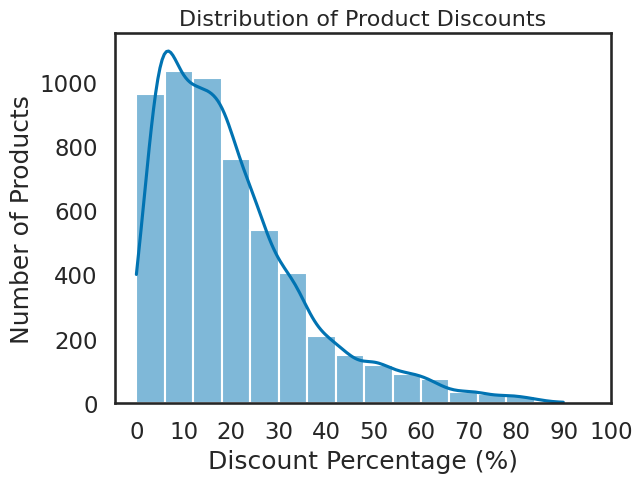

In [ ]:
import matplotlib.pyplot as plt

# How many products are being discounted?
discounted_product = products_qu[products_qu['discount'] > 0.01]
discounted_product['discount'].count() # 5440 / 5753 are discounted

# % of products discounted -- 94.56%
percentage_discounted = round(
    discounted_product.shape[0] / products_qu.shape[0] * 100,
    2
)

#Average discount % -- 19.94
discounted_product['order_discount_percentage(%)'].mean()

# Discount distribution
sns.set_theme(
    style="white",
    context="talk",
    palette="colorblind"
)

discount_plot = sns.histplot(
    data=products_qu[products_qu['discount'] > 0],
    x='order_discount_percentage(%)',
    bins=15,
    binwidth=6,
    kde=True
)

discount_plot.set_title(
    'Distribution of Product Discounts',
    fontsize=16
)

discount_plot.set_xlabel(
    'Discount Percentage (%)'
)

discount_plot.set_ylabel(
    'Number of Products'
)

discount_plot.set_xticks(range(0, 101, 10))